In [2]:
import sys
sys.path.append("../")
import numpy as np
from utils.noise_generator import ColoredNoiseGenerator_Cholesky

def build_C_from_alpha(alpha, tgrid):
    N = len(tgrid)
    C = np.zeros((N, N), dtype=complex)
    for i in range(N):
        for j in range(N):
            C[i, j] = alpha(tgrid[j] - tgrid[i])
    return C

def rel_fro_error(A, B, eps=1e-15):
    return np.linalg.norm(A - B, 'fro') / (np.linalg.norm(B, 'fro') + eps)

def alpha(t):
    g = 2
    w = 0.5 + 2j
    a = lambda t: g * np.exp(-w * t)
    if t >= 0:
        return a(t)
    else:
        return np.conj(a(-t))

steps = 10
tmax = np.pi
dt = tmax / steps
tgrid = np.linspace(0, tmax, steps + 1)

C = build_C_from_alpha(alpha, tgrid)

noise_generator = ColoredNoiseGenerator_Cholesky(alpha, t_stop=tmax, N_steps=steps)

N_samples = 100000
C_hat = 0

for n in range(N_samples):
    z = noise_generator.sample_process()
    C_hat += np.outer(z, z.conj())

C_hat /= N_samples

print("Relative Frobenius error:", rel_fro_error(C_hat, C))

Relative Frobenius error: 0.0060484344958535415


In [2]:
# bath correlation function in Cai_2020_CPAM
Delta = 1
beta = 5/Delta
wc = 2.5 * Delta
wmax = 4 * wc
CapL = 200
factor = 1 - np.exp(-wmax/wc)
wl = -wc * np.log(1 - np.linspace(1, CapL, CapL)/CapL * factor)
cl = wl * np.sqrt((0.2 * wc/CapL) * factor)

_coth = 1.0 / np.tanh(0.5 * beta * wl)
_pref = (cl**2) / (2.0 * wl)
def bath_corr(t):
    """
    Bath correlation function alpha(t).
    Supports scalar t or 1D array t (returns same shape).
    """
    # t_arr = np.asarray(t)
    # t1 = np.atleast_1d(t_arr).astype(float)
    # phase = wl[:, None] * t1[None, :]             # shape: (CapL, len(t))
    # out = np.sum(_pref[:, None] * (np.cos(phase) * _coth[:, None] - 1j * np.sin(phase)), axis=0)
    # return out[0] if t_arr.ndim == 0 else out
    res = 0
    for l in range(CapL):
        res += _pref[l] * (_coth[l] * np.cos(wl[l]*t) - 1j * np.sin(wl[l]*t))
    return res

tmax = 5/Delta
steps = 50
dt = tmax / steps
tgrid = np.linspace(0, tmax, steps + 1)


noise_generator = ColoredNoiseGenerator_Cholesky(bath_corr, t_stop=tmax, N_steps=steps)

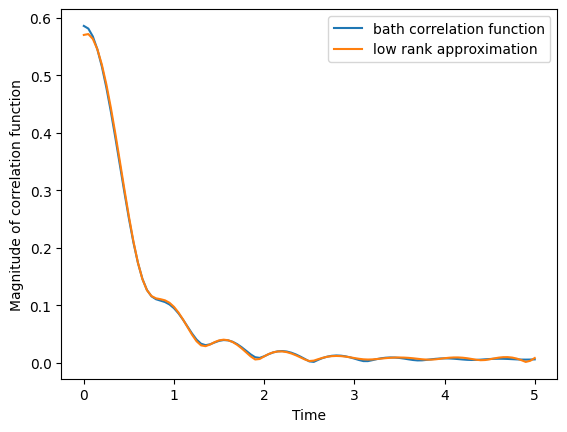

In [ ]:
import matplotlib.pyplot as plt

# SIAM-style plotting setup: clean, publication-friendly, and readable in grayscale.
plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "font.family": "serif",
    "mathtext.fontset": "stix",
    "font.size": 10,
    "axes.labelsize": 16,
    "axes.titlesize": 20,
    "axes.linewidth": 0.8,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.minor.size": 2.5,
    "ytick.minor.size": 2.5,
    "legend.fontsize": 14,
    "legend.frameon": False,
})

def apply_light_paper_grid(ax):
    # 主网格：稍微深一点，用细实线
    ax.grid(which="major", color="#DDDDDD", linestyle='-', alpha=0.6, lw=0.6)
    # 次网格：非常浅，用点线或极细虚线 (这是目前代码缺失的关键)
    ax.grid(which="minor", color="#EEEEEE", linestyle=':', alpha=0.3, lw=0.4)
    # 隐藏不必要的刻度线（可选，增加简洁度）
    ax.tick_params(which='major', direction='in')

rank = 10
steps = 100
tgrid = np.linspace(0, tmax, steps + 1)
dt = tmax / steps
C = np.zeros((steps + 1, steps + 1), dtype=complex)
for i in range(steps + 1):
    for j in range(steps + 1):
        C[i, j] = bath_corr(tgrid[i] - tgrid[j])
U, S, V = np.linalg.svd(dt * C)
U = U / np.sqrt(dt)
V = V / np.sqrt(dt)

U_ = U[:, :rank]
V_ = V[:rank, :]
C_ = U_ @ np.diag(S[:rank]) @ V_

# bath correlation function in Cai_2020_CPAM
Delta = 1
beta = 5/Delta
wc = 2.5 * Delta
wmax = 4 * wc
CapL = 200
factor = 1 - np.exp(-wmax/wc)
wl = -wc * np.log(1 - np.linspace(1, CapL, CapL)/CapL * factor)
cl = wl * np.sqrt((0.2 * wc/CapL) * factor)
_coth = 1.0 / np.tanh(0.5 * beta * wl)
_pref = (cl**2) / (2.0 * wl)
def bath_corr_prin_comp(t):
    res = 0
    for l in range(rank):
        res += _pref[l] * (_coth[l] * np.cos(wl[l]*t) - 1j * np.sin(wl[l]*t))
    return res
prin_comp = np.array([bath_corr_prin_comp(t) for t in tgrid])

plt.plot(tgrid, np.abs(C[:,0]), color="#222222", lw=1.3, ls="--", label='Exact BCF', zorder=5)
plt.plot(tgrid, np.abs(C_[:,0]), color="tab:blue", lw=1.9, label=r'Approximation ($r=10$)')
# plt.plot(tgrid, np.abs(prin_comp), label='principal components')
plt.legend(loc="best")
plt.xlabel(r'$t-s$')
plt.ylabel(r'$|\alpha(t-s)|$')
plt.grid(which="major", color="#DDDDDD", linestyle='-', alpha=0.6, lw=0.6)
plt.grid(which="minor", color="#EEEEEE", linestyle=':', alpha=0.3, lw=0.4)
plt.tick_params(which='major', direction='in')
plt.savefig("figures/Ohmic_BCF_approx.eps", format="eps")
plt.show()

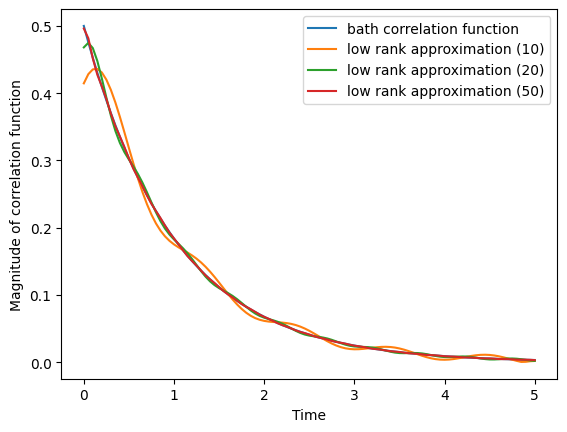

In [ ]:
import matplotlib.pyplot as plt

# SIAM-style plotting setup: clean, publication-friendly, and readable in grayscale.
plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "font.family": "serif",
    "mathtext.fontset": "stix",
    "font.size": 10,
    "axes.labelsize": 16,
    "axes.titlesize": 20,
    "axes.linewidth": 0.8,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.minor.size": 2.5,
    "ytick.minor.size": 2.5,
    "legend.fontsize": 14,
    "legend.frameon": False,
})

def apply_light_paper_grid(ax):
    # 主网格：稍微深一点，用细实线
    ax.grid(which="major", color="#DDDDDD", linestyle='-', alpha=0.6, lw=0.6)
    
    # 次网格：非常浅，用点线或极细虚线 (这是目前代码缺失的关键)
    ax.grid(which="minor", color="#EEEEEE", linestyle=':', alpha=0.3, lw=0.4)
    
    # 隐藏不必要的刻度线（可选，增加简洁度）
    ax.tick_params(which='major', direction='in')

g = 2
w = 0.5+2j
tmax = 2
steps = 100
tgrid = np.linspace(0, tmax, steps + 1)
dt = tmax / steps
C = np.zeros((steps + 1, steps + 1), dtype=complex)
for i in range(steps + 1):
    for j in range(steps + 1):
        C[i, j] = 2 * np.exp(-4*np.abs(tgrid[i] - tgrid[j]))
        # if i >= j:
        #     C[i,j] = g * np.exp(-w * (tgrid[i] - tgrid[j]))
        # else:
        #     C[i,j] = np.conj(g * np.exp(-w * (tgrid[j] - tgrid[i])))
U, S, V = np.linalg.svd(dt * C)
U = U / np.sqrt(dt)
V = V / np.sqrt(dt)

U_10 = U[:, :10]
V_10 = V[:10, :]
C_10 = U_10 @ np.diag(S[:10]) @ V_10

U_20 = U[:, :20]
V_20 = V[:20, :]
C_20 = U_20 @ np.diag(S[:20]) @ V_20

U_50 = U[:, :50]
V_50 = V[:50, :]
C_50 = U_50 @ np.diag(S[:50]) @ V_50


# 1. 基准线：置于顶层 (zorder=5)，稍微细一点，半透明虚线
plt.plot(tgrid, np.abs(C[:,0]), 
         color="#222222", lw=1.0, ls="--", label='Exact BCF', zorder=5)

# 2. r=10：使用冷色调，线条稍细，表达“初步近似”
plt.plot(tgrid, np.abs(C_10[:,0]), 
         color="#4A90E2", lw=1.6, alpha=0.8, label=r'Approximation ($r=10$)')

# 3. r=50：使用暖色或更深的颜色，线条加粗，表达“精确拟合”
plt.plot(tgrid, np.abs(C_50[:,0]), 
         color="#E64B35", lw=2.0, label=r'Approximation ($r=50$)')

plt.grid(which="major", color="#DDDDDD", linestyle='-', alpha=0.6, lw=0.6)
    
# 次网格：非常浅，用点线或极细虚线 (这是目前代码缺失的关键)
plt.grid(which="minor", color="#EEEEEE", linestyle=':', alpha=0.3, lw=0.4)

# 隐藏不必要的刻度线（可选，增加简洁度）
plt.tick_params(which='both', direction='in')

# --- 细节增强 ---
plt.legend() # 去掉图例边框，更有现代感
plt.ylabel(r'$|\alpha(t-s)|$')
plt.xlabel(r'$t-s$')
# plt.legend(loc="best")
# plt.xlabel(r'$t-s$')
# plt.ylabel(r'$|\alpha(t-s)|$')
plt.minorticks_on()
plt.grid(which="major", alpha=0.28, lw=0.6)
plt.savefig("figures/exp_BCF_approx.eps", format="eps")
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append("../")
from utils.noise_generator import ColoredNoiseGenerator_Cholesky

# ==========================================
# Cai_2020_CPAM bath discretization (your code)
# ==========================================
Delta = 1
beta = 5/Delta
wc = 2.5 * Delta
wmax = 4 * wc
CapL = 200

factor = 1 - np.exp(-wmax/wc)
wl = -wc * np.log(1 - np.linspace(1, CapL, CapL)/CapL * factor)   # omega_l
cl = wl * np.sqrt((0.2 * wc/CapL) * factor)

_coth = 1.0 / np.tanh(0.5 * beta * wl)                             # coth(beta omega/2)
_pref = (cl**2) / (2.0 * wl)                                       # pref_l = c_l^2/(2 omega_l)

def bath_corr(t):
    t_arr = np.asarray(t)
    t1 = np.atleast_1d(t_arr).astype(float)
    phase = wl[:, None] * t1[None, :]
    out = np.sum(_pref[:, None] * (np.cos(phase) * _coth[:, None] - 1j * np.sin(phase)), axis=0)
    return out[0] if t_arr.ndim == 0 else out

# ==========================================
# Proper complex Gaussian noise satisfying:
# E z = 0, E zz = 0, E z(t) z(s)^* = alpha(t-s)
# z(t)= sum sqrt(pref_l) [ A_l xi_l e^{-i w_l t} + B_l eta_l e^{+i w_l t} ]
# A_l^2=(coth_l+1)/2, B_l^2=(coth_l-1)/2
# xi,eta iid CN(0,1), independent
# ==========================================
A = np.sqrt((_coth + 1.0) / 2.0)   # (L,)
B = np.sqrt((_coth - 1.0) / 2.0)   # (L,)
sqrt_pref = np.sqrt(_pref)         # (L,)

def sample_cn01(rng, shape):
    # proper complex N(0,1): E[zz]=0, E[|z|^2]=1
    return (rng.standard_normal(shape) + 1j * rng.standard_normal(shape)) / np.sqrt(2.0)

def noise_on_grid(tgrid, xi, eta):
    """
    tgrid: (N,)
    xi, eta: (M,L) CN(0,1)
    returns Z: (M,N)
    """
    # exp matrices: (N,L)
    Eminus = np.exp(-1j * np.outer(tgrid, wl))
    Eplus  = np.exp(+1j * np.outer(tgrid, wl))

    # weights: (L,)
    w1 = sqrt_pref * A
    w2 = sqrt_pref * B

    # (M,L)@(L,N) -> (M,N)
    Z = (xi * w1[None, :]) @ Eminus.T + (eta * w2[None, :]) @ Eplus.T
    return Z

# ==========================================
# Random ODE: X' = mu X + sigma X z(t)
# Euler & reference (via trapezoid in exponent)
# ==========================================
def euler_solver(mu, sigma, x0, T, Z):
    M, Np1 = Z.shape
    N = Np1 - 1
    dt = T / N
    X = np.full(M, x0, dtype=np.complex128)
    for n in range(N):
        X = X + (mu * X + sigma * X * Z[:, n]) * dt
    return X

def reference_solution(mu, sigma, x0, T, Zref):
    M, Np1 = Zref.shape
    Nref = Np1 - 1
    dt = T / Nref
    I = dt * (0.5 * Zref[:, 0] + Zref[:, 1:-1].sum(axis=1) + 0.5 * Zref[:, -1])
    return x0 * np.exp(mu * T + sigma * I)

def fit_order(dts, errs):
    return np.polyfit(np.log(dts), np.log(errs), 1)[0]

def main():
    # ---- experiment params ----
    rng = np.random.default_rng(2026)
    M = 50000          # increase if weak tail noisy
    T = 1.0

    mu = 1.0
    sigma = 0.5
    x0 = 1.0

    # ---- sample xi, eta once (same noise paths for all dt) ----
    xi  = sample_cn01(rng, (M, CapL))
    eta = sample_cn01(rng, (M, CapL))

    # ---- (A) quick Monte-Carlo check of the 3 conditions ----
    # pick a few times
    tcheck = np.array([0.0, 0.25, 0.5, 0.75, 1.0])
    # Zc = noise_on_grid(tcheck, xi, eta)  # (M, len(tcheck))
    # generate noise trajectories for strong error
    Zc = np.empty((M, 5), dtype=np.complex128)
    noise_gen = ColoredNoiseGenerator_Cholesky(bath_corr, 1.0, 4)
    for traj in range(M):
        z = np.asarray(noise_gen.sample_process(), dtype=np.complex128)
        Zc[traj, :] = z[:]

    # E[z_t] ~ 0
    Ez = Zc.mean(axis=0)

    # check E[z(t_i) z(t_j)] ~ 0 and E[z(t_i) z(t_j)^*] ~ alpha(t_i - t_j)
    # compute empirical covariances
    Emp_zz   = (Zc[:, :, None] * Zc[:, None, :]).mean(axis=0)              # (k,k)
    Emp_zzc  = (Zc[:, :, None] * np.conj(Zc[:, None, :])).mean(axis=0)     # (k,k)

    # theory alpha(t_i - t_j)
    Dt = tcheck[:, None] - tcheck[None, :]
    Th = np.vectorize(bath_corr)(-Dt)

    print("Check E[z(t)] (should be ~0):")
    print(Ez)

    print("\nMax |E[z(t_i) z(t_j)]| (should be small):", np.max(np.abs(Emp_zz)))
    print("Max |E[z(t_i) z(t_j)^*] - alpha(t_i-t_j)|:", np.max(np.abs(Emp_zzc - Th)))

    # ---- (B) convergence test ----
    # reference on fine grid
    Nref = 2**10
    t_ref = np.linspace(0.0, T, Nref + 1)

    # Zref = noise_on_grid(t_ref, xi, eta)
    Zref = np.empty((M, Nref+1), dtype=np.complex128)
    noise_gen = ColoredNoiseGenerator_Cholesky(bath_corr, T, Nref)
    for traj in range(M):
        z = np.asarray(noise_gen.sample_process(), dtype=np.complex128)
        Zref[traj, :] = z[:]

    Xref = reference_solution(mu, sigma, x0, T, Zref)
    # Xref = euler_solver(mu, sigma, x0, T, Zref)

    ks = np.array([4, 5, 6, 7, 8], dtype=int)  # N=16..1024
    Ns = 2**ks
    dts = T / Ns

    strong_err = []
    weak_err = []

    for N in Ns:
        t = np.linspace(0.0, T, N + 1)

        # Z = noise_on_grid(t, xi, eta)
        Z = np.empty((M, N+1), dtype=np.complex128)
        # noise_gen = ColoredNoiseGenerator_Cholesky(bath_corr, T, N)
        # for traj in range(M):
        #     z = np.asarray(noise_gen.sample_process(), dtype=np.complex128)
        #     Z[traj, :] = z[:]
        for traj in range(M):
            Z[traj, :] = Zref[traj, ::(Nref//N)]  # subsample from fine grid

        Xnum = euler_solver(mu, sigma, x0, T, Z)

        se = np.mean(np.abs(Xnum - Xref))                 # strong
        we = np.abs(np.mean(Xnum) - np.mean(Xref))        # weak

        strong_err.append(se)
        weak_err.append(we)
        print(f"N={N:4d}, dt={T/N:.3e}, strong={se:.3e}, weak={we:.3e}")

    strong_err = np.array(strong_err)
    weak_err = np.array(weak_err)

    pS = fit_order(dts, strong_err)
    pW = fit_order(dts, weak_err)
    print(f"\nObserved orders: strong ≈ {pS:.3f}, weak ≈ {pW:.3f}")

    # plot both on one figure
    plt.figure(figsize=(8, 6))
    plt.loglog(dts, strong_err, "o-", label=f"Strong (≈{pS:.2f})")
    plt.loglog(dts, weak_err,   "s-", label=f"Weak   (≈{pW:.2f})")

    # reference slope 1
    C = strong_err[0] / dts[0]
    plt.loglog(dts, C * dts, "--", label="Ref slope 1")

    plt.gca().invert_xaxis()
    plt.xlabel("dt")
    plt.ylabel("Error")
    plt.title("Euler convergence with Cai bath proper complex noise")
    plt.grid(True, which="both", linestyle=":")
    plt.legend()
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()

In [5]:
import numpy as np

arr1 = np.random.rand(3, 2, 2)
arr2 = np.random.rand(3, 2, 2)

print("arr1:", arr1)
print("arr2:", arr2)

err = arr1 - arr2
err_norm = np.linalg.norm(err, axis=-1)
print(err_norm.shape)
print(err_norm)

traj_max = err_norm.max(axis=-1)
print(traj_max.shape)
print(traj_max)

res = traj_max.mean()
print("Result:", res)

arr1: [[[0.07744215 0.64786648]
  [0.35928071 0.15331727]]

 [[0.54485731 0.18757622]
  [0.24999306 0.68394656]]

 [[0.1013178  0.54027706]
  [0.25587302 0.6907782 ]]]
arr2: [[[0.48008365 0.03185256]
  [0.39544927 0.48403485]]

 [[0.72808085 0.31572746]
  [0.40450321 0.64688634]]

 [[0.15594822 0.87981002]
  [0.44820721 0.1755196 ]]]
(3, 2)
[[0.73593024 0.33268947]
 [0.22359251 0.15889256]
 [0.34389986 0.54998533]]
(3,)
[0.73593024 0.22359251 0.54998533]
Result: 0.5031693615517778


In [5]:
a = [[],[],[]]
a[0].append(1)
a[1].append(2)
a[2].append(3)
print(a[0])

[1]
